# Ranking engine evaluation: weight sensitivity

[ARCHITECTURE.md §3.9](../ARCHITECTURE.md#39-ranking_engine).

Model B's weights (`w1=0.4, w2=0.25, w3=0.2, w4=0.15`) are first-guess defaults — chosen to make A vs B a sharp contrast (see `ARCHITECTURE.md` v2), never tuned or checked for sensitivity. This notebook asks two questions the Streamlit "Model Comparison" tab can't (it only shows one weight configuration at a time):

1. **Weight sensitivity** — how much does `w4` (the trend-lifecycle weight, the one dimension B adds beyond a plain attribute+trend match) actually move the ranking? If varying it barely changes anything, the "lifecycle-awareness" story is weaker than it looks.
2. **Cross-profile comparison** — `rank_catalog.py` reports Kendall's tau/top-5 overlap one profile at a time. Plotted together, do some profiles behave very differently from others, and is there a pattern in *why*?

Both questions need real code and plots, which is why this is a notebook and not a Streamlit tab (per `ARCHITECTURE.md` v10's note on the same distinction).

## 1. Setup

In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
import yaml

from fashion_forensics.nlp.lifecycle_classifier import load_lifecycle_states
from fashion_forensics.nlp.ranking_engine import (
    DEFAULT_WEIGHTS_B,
    filter_fair_comparison_subset,
    kendall_tau,
    load_ranking_catalog,
    rank_items,
    top_k_overlap,
)

PROFILES_PATH = PROJECT_ROOT / "configs" / "user_profiles.yaml"
profiles = yaml.safe_load(PROFILES_PATH.read_text())["profiles"]

COLOR_BY_PROFILE = {
    "synthetic_user_rising_basics": "#9ACD32",
    "synthetic_user_persistent_luxury": "#8D6E63",
    "synthetic_user_seasonal_mobwife": "#1B5E20",
    "synthetic_user_inactive_officesiren": "#607D8B",
}

catalog = load_ranking_catalog()
lifecycle_by_trend = load_lifecycle_states()
subset = filter_fair_comparison_subset(catalog)

print(f"Full catalog: {len(catalog)} items")
print(f"Fair-comparison subset (has both attributes and a real trend label): {len(subset)} items")
print(f"Profiles: {list(profiles.keys())}")
print(f"Default weights (Model B): {DEFAULT_WEIGHTS_B}")

2026-08-27 09:13:40.458 | INFO     | fashion_forensics.nlp.ranking_engine:filter_fair_comparison_subset:370 - Fair-comparison subset: 50/2029 items (has both normalized attributes and a real trend label)


Full catalog: 2029 items
Fair-comparison subset (has both attributes and a real trend label): 50 items
Profiles: ['synthetic_user_rising_basics', 'synthetic_user_persistent_luxury', 'synthetic_user_seasonal_mobwife', 'synthetic_user_inactive_officesiren']
Default weights (Model B): {'w1': 0.4, 'w2': 0.25, 'w3': 0.2, 'w4': 0.15}


## 2. Weight sensitivity: how much does `w4` move the ranking?

`score_b` is `w1*attribute_match + w2*trend_match + w3*category_match + w4*(trend_state_weight * trend_match)`. `w4` is the only piece that makes Model B different from a plain attribute+trend+category score, so this is the number that decides whether "lifecycle-aware ranking" is a real product feature or a rounding error.

We sweep `w4` from 0 (lifecycle ignored entirely) up to 0.5 (half the score), keeping `w1:w2:w3` at the same ratio as the default weights and rescaling them so everything still sums to 1. At each step we re-rank every profile's fair-comparison subset and compare that ranking to the ranking produced by the actual default weights (`w4=0.15`), using the same `kendall_tau`/`top_k_overlap` metrics `rank_catalog.py` already trusts for A vs B.

In [2]:
W4_SWEEP = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]

base_w1, base_w2, base_w3 = (
    DEFAULT_WEIGHTS_B["w1"],
    DEFAULT_WEIGHTS_B["w2"],
    DEFAULT_WEIGHTS_B["w3"],
)
base_sum = base_w1 + base_w2 + base_w3  # 0.85, the part of the score w4 competes with


def weights_for_w4(w4: float) -> dict:
    """Rescale w1/w2/w3 so they keep the default's ratio and everything sums to 1."""
    remaining = 1 - w4
    scale = remaining / base_sum
    return {"w1": base_w1 * scale, "w2": base_w2 * scale, "w3": base_w3 * scale, "w4": w4}


default_ranked_by_profile = {
    name: rank_items(subset, profile, model="B", lifecycle_by_trend=lifecycle_by_trend)
    for name, profile in profiles.items()
}

sweep_rows = []
for name, profile in profiles.items():
    baseline = default_ranked_by_profile[name]
    for w4 in W4_SWEEP:
        weights = weights_for_w4(w4)
        ranked = rank_items(
            subset, profile, model="B", lifecycle_by_trend=lifecycle_by_trend, weights=weights
        )
        sweep_rows.append(
            {
                "profile": name,
                "w4": w4,
                "kendall_tau_vs_default": kendall_tau(baseline, ranked),
                "top5_overlap_vs_default": top_k_overlap(baseline, ranked, k=5),
            }
        )

sweep_df = pd.DataFrame(sweep_rows)
sweep_df[sweep_df["profile"] == "synthetic_user_inactive_officesiren"]

,profile,w4,kendall_tau_vs_default,top5_overlap_vs_default
24,synthetic_user_inactive_officesiren,0.00,0.913469,0.428571
25,synthetic_user_inactive_officesiren,0.05,0.913469,0.428571
26,synthetic_user_inactive_officesiren,0.10,0.913469,0.428571
27,synthetic_user_inactive_officesiren,0.15,1.000000,1.000000
28,synthetic_user_inactive_officesiren,0.20,1.000000,1.000000
29,synthetic_user_inactive_officesiren,0.30,1.000000,1.000000
30,synthetic_user_inactive_officesiren,0.40,0.871020,0.666667
31,synthetic_user_inactive_officesiren,0.50,0.871020,0.666667


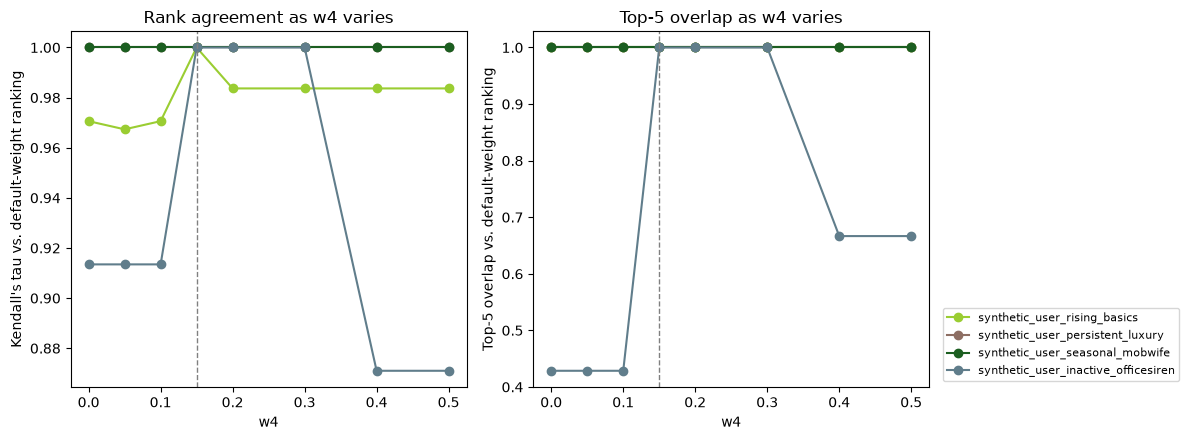

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for name in profiles:
    profile_df = sweep_df[sweep_df["profile"] == name]
    color = COLOR_BY_PROFILE[name]
    axes[0].plot(
        profile_df["w4"], profile_df["kendall_tau_vs_default"], marker="o", color=color, label=name
    )
    axes[1].plot(
        profile_df["w4"], profile_df["top5_overlap_vs_default"], marker="o", color=color, label=name
    )

axes[0].axvline(DEFAULT_WEIGHTS_B["w4"], color="gray", linestyle="--", linewidth=1)
axes[1].axvline(DEFAULT_WEIGHTS_B["w4"], color="gray", linestyle="--", linewidth=1)
axes[0].set_xlabel("w4")
axes[0].set_ylabel("Kendall's tau vs. default-weight ranking")
axes[0].set_title("Rank agreement as w4 varies")
axes[1].set_xlabel("w4")
axes[1].set_ylabel("Top-5 overlap vs. default-weight ranking")
axes[1].set_title("Top-5 overlap as w4 varies")
axes[1].legend(loc="lower left", fontsize=8, bbox_to_anchor=(1.02, 0))
fig.tight_layout()
plt.show()

## 3. Cross-profile comparison: Model A vs Model B (default weights)

`rank_catalog.py` computes `kendall_tau`/`top5_overlap` between Model A and Model B one profile at a time and writes them to `model_comparison_summary.csv`. Here we compute the same thing for all four profiles side by side, to see whether lifecycle-awareness reshuffles some profiles' rankings more than others.

In [4]:
comparison_rows = []
for name, profile in profiles.items():
    ranked_a = rank_items(subset, profile, model="A")
    ranked_b = default_ranked_by_profile[name]
    comparison_rows.append(
        {
            "profile": name,
            "prefer_rising": profile.get("prefer_rising", False),
            "avoid_declining": profile.get("avoid_declining", False),
            "kendall_tau": kendall_tau(ranked_a, ranked_b),
            "top5_overlap": top_k_overlap(ranked_a, ranked_b, k=5),
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,profile,prefer_rising,avoid_declining,kendall_tau,top5_overlap
0,synthetic_user_rising_basics,True,True,0.717551,0.428571
1,synthetic_user_persistent_luxury,False,True,0.582041,0.428571
2,synthetic_user_seasonal_mobwife,True,False,0.920000,0.428571
3,synthetic_user_inactive_officesiren,False,True,0.923265,0.666667


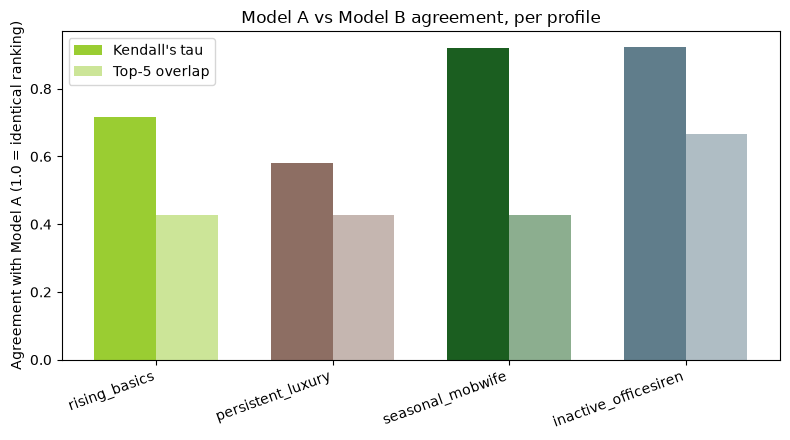

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = range(len(comparison_df))
width = 0.35
colors = [COLOR_BY_PROFILE[name] for name in comparison_df["profile"]]

ax.bar(
    [i - width / 2 for i in x],
    comparison_df["kendall_tau"],
    width,
    label="Kendall's tau",
    color=colors,
)
ax.bar(
    [i + width / 2 for i in x],
    comparison_df["top5_overlap"],
    width,
    label="Top-5 overlap",
    color=colors,
    alpha=0.5,
)
ax.set_xticks(list(x))
ax.set_xticklabels(
    [n.replace("synthetic_user_", "") for n in comparison_df["profile"]], rotation=20, ha="right"
)
ax.set_ylabel("Agreement with Model A (1.0 = identical ranking)")
ax.set_title("Model A vs Model B agreement, per profile")
ax.legend()
fig.tight_layout()
plt.show()

In [6]:
from collections import Counter

trend_counts = Counter(item["trend_pred"] for item in subset)
print("Fair-comparison subset, items per trend:", dict(trend_counts))
print()
print("Kendall's tau vs. default-weight ranking, by w4:")
print(
    sweep_df.pivot(index="w4", columns="profile", values="kendall_tau_vs_default")
    .round(3)
    .to_string()
)
print()
print("Top-5 overlap vs. default-weight ranking, by w4:")
print(
    sweep_df.pivot(index="w4", columns="profile", values="top5_overlap_vs_default")
    .round(3)
    .to_string()
)

Fair-comparison subset, items per trend: {'basics': 12, 'office_siren': 5, 'quiet_luxury': 30, 'mob_wife': 3}

Kendall's tau vs. default-weight ranking, by w4:
profile  synthetic_user_inactive_officesiren  synthetic_user_persistent_luxury  synthetic_user_rising_basics  synthetic_user_seasonal_mobwife
w4                                                                                                                                           
0.00                                   0.913                               1.0                         0.971                              1.0
0.05                                   0.913                               1.0                         0.967                              1.0
0.10                                   0.913                               1.0                         0.971                              1.0
0.15                                   1.000                               1.0                         1.000                      

## 4. Conclusions

**Why w4 barely moves most rankings.** `lifecycle_by_trend` (from `lifecycle_states.jsonl`) holds one state per *trend*, not per item - every item of a given trend in the fair-comparison subset gets the exact same `trend_state_weight`. That means `w4` can only ever widen or narrow the score gap between "on-trend" and "off-trend" items; it structurally cannot reorder items *within* the same trend, no matter how large it gets. For 3 of the 4 profiles that gap-widening never happens to cross another item's score in this 50-item subset, so the ranking is untouched across the entire w4 sweep (0 to 0.5) - that's not a bug, it's what a per-trend-constant bonus predicts.

`inactive_officesiren` is the exception because it's the only profile whose lifecycle weight is *negative* (`avoid_declining` engages on `office_siren`'s current `inactive` state, tsw = -0.5). A negative w4 term pushes on-trend items *down* as w4 grows, which is far more likely to produce an actual crossover with off-trend items than the positive-tsw profiles' "push further ahead of an already-comfortable lead" case - and that's exactly the one profile where kendall's tau (0.87-1.0) and top-5 overlap (0.43-1.0) actually move.

**So is lifecycle-awareness a real feature or a rounding error?** Neither, precisely - it's a real but blunt instrument as currently built. It correctly demotes items on a trend the user wants to avoid, but it can't do anything more granular than that (e.g. distinguish an item that entered the catalog as `basics` just started rising vs. one that's been there the whole time) because there's no per-item time dimension in `trend_state_weight`, only a per-trend global snapshot. If richer lifecycle-awareness is wanted, the state lookup would need to vary by the item's own month relative to the trend curve, not just the trend's current state.

**The A vs B disagreement (tau 0.58-0.92, section 3) is mostly about w2, not w4.** Model A has zero notion of trend at all - the gap between A and B's rankings is dominated by `w2*trend_match`, which A entirely lacks, not by the lifecycle bonus. The original framing ("does lifecycle-awareness reshuffle rankings?") conflated two separate additions B makes over A; decomposed, trend-matching does the heavy lifting and lifecycle-awareness is the much smaller, mostly-boundary-only effect described above.

**Two things worth flagging, not fixing here:**
- The fair-comparison subset is small and skewed (50 items: quiet_luxury 30, basics 12, office_siren 5, mob_wife 3) - the `seasonal_mobwife`/`inactive_officesiren` numbers above rest on very few items and should be treated as suggestive, not conclusive.
- `configs/user_profiles.yaml`'s inline "real lifecycle state" comments had drifted from the actual current `lifecycle_states.jsonl` for 2 of 4 profiles (`persistent_luxury`'s trend is now `rising`, `seasonal_mobwife`'s is now `persistent`) - fixed as part of this notebook's write-up. The profile *names* still reflect the state at creation time and were left as mnemonics rather than renamed, since the state will keep drifting as the lifecycle classifier is re-run.

In [7]:
# Verify the "one state per trend" claim and each profile's actual current tsw
from fashion_forensics.nlp.ranking_engine import trend_state_weight

print(f"{'profile':40s} {'trend':14s} {'state':20s} {'tsw':>6s}")
for name, profile in profiles.items():
    trend = profile["preferred_trends"][0]
    state = lifecycle_by_trend[trend]["state"]
    tsw = trend_state_weight(state, profile["prefer_rising"], profile["avoid_declining"])
    print(f"{name:40s} {trend:14s} {state:20s} {tsw:+.2f}")

profile                                  trend          state                   tsw
synthetic_user_rising_basics             basics         rising               +1.00
synthetic_user_persistent_luxury         quiet_luxury   rising               +0.30
synthetic_user_seasonal_mobwife          mob_wife       persistent           +0.50
synthetic_user_inactive_officesiren      office_siren   inactive             -0.50
